# Wavefield · Elastic TTI rotation

`ElasticTTI` is the elastic anisotropic equation with a *tilted* transverse-isotropy axis — the symmetry axis can point anywhere via two angles (θ, φ). This is the canonical model for fractured / dipping shales.

The notebook fires one explosion source in a uniform anisotropic medium and rotates the symmetry axis through three settings:

| Case | θ (dip) | φ (azimuth) |
|---|---|---|
| `VTI 0/0` | 0° | 0° — vertical axis (standard VTI) |
| `TTI 35/0` | 35° | 0° — axis dipping in the x-z plane |
| `TTI 35/45` | 35° | 45° — axis dipping out of plane (3-D effect visible in Vy) |

Snapshots of the Vz wavefield at three times show the qP wavefront tilt with the rotation.

## 1. Parameters

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from sweep.equations import ElasticTTI
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker

# Mirrors examples/wavefields/anisotropic/elastic_tti_wavefields.py (full mode)
shape = (600, 600)             # 3 km × 3 km at 5 m spacing
dh    = 5.0
dt    = 2.5e-4
nt    = 1800                   # 0.45 s record
abcn  = 60                     # PML width
spatial_order = 8
freq, delay = 30.0, 0.04
snapshot_times = (500, 1000, 1600)

src_radius = 2                  # 5×5 grid of source points
src_sigma  = 1.2                # Gaussian falloff (grid cells)

vp_val, vs_val, rho_val = 2400.0, 1200.0, 2200.0
epsilon_val, delta_val, gamma_val = 0.35, 0.05, 0.20  # Thomsen parameters

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## 2. Uniform anisotropic model

`ElasticTTI` consumes **eight** model fields: `vp, vs, rho, ε, δ, γ, θ, φ`. The first six are constants; `θ` and `φ` are what we'll sweep.

In [2]:
def build_models(theta_deg, phi_deg):
    full = lambda v: torch.full(shape, float(v), dtype=torch.float32, device=device)
    return [
        full(vp_val), full(vs_val), full(rho_val),
        full(epsilon_val), full(delta_val), full(gamma_val),
        full(np.deg2rad(theta_deg)),
        full(np.deg2rad(phi_deg)),
    ]

## 3. Solver and source

In [3]:
eq = ElasticTTI(spatial_order=spatial_order, device=device)
solver = PropTorch(eq, shape=shape, dh=dh, dt=dt, dev=device,
                   abcn=abcn, source_type=['sxx', 'szz'], receiver_type=['vx', 'vy', 'vz'],
                   impl='eager', use_ckpt=False)

# Gaussian 5x5 explosion source at the model centre (mirrors the old script)
cx, cz = shape[1] // 2, shape[0] // 2
src_points  = []
src_weights = []
for dz in range(-src_radius, src_radius + 1):
    for dx in range(-src_radius, src_radius + 1):
        src_points.append([cx + dx, cz + dz])
        src_weights.append(np.exp(-0.5 * (dx * dx + dz * dz) / (src_sigma * src_sigma)))
src_weights = np.asarray(src_weights, dtype=np.float32)
src_weights /= src_weights.sum()

sources   = np.asarray(src_points, dtype=np.int64)[None, ...]     # (1, 25, 2)
receivers = np.asarray([[[cx, cz]]], dtype=np.int64)              # dummy single receiver

# Per-source weighted wavelet — Gaussian envelope across the 5x5 grid
t = np.arange(nt, dtype=np.float32) * dt - delay
ricker_t = (1e3 * ricker(t, f=freq)).astype(np.float32)
wavelet  = (src_weights[:, None] * ricker_t[None, :]).astype(np.float32)
# wavelet shape: (25, nt)  — per-source weighted, source encoding (sources has leading dim 1)

### Aside · which sources and receivers does this equation accept?

`ElasticTTI` publishes a structured field table — query `eq.models` for the
expected model input order, `available_source_fields()` / `available_receiver_fields()`
for valid source / receiver options. See the
[Equations user guide](../../user-guide/equations/) for the full rundown.

In [4]:
print('models (input order matters!):')
for spec in eq.MODEL_SPECS:
    unit = f' [{spec.unit}]' if spec.unit else ''
    print(f'  - {spec.name:8s}{unit}  — {spec.description}')
print('defaults  :', eq.default_source_fields, '/', eq.default_receiver_fields)
print('receivers :')
for spec in eq.available_receiver_fields():
    print(f'  - {spec.name:8s} aliases={spec.aliases}  — {spec.description}')

models (input order matters!):
  - vp0      [m/s]  — VTI-frame vertical P velocity.
  - vs0      [m/s]  — VTI-frame vertical S velocity.
  - rho      [kg/m^3]  — Density.
  - epsilon   — Thomsen epsilon.
  - delta     — Thomsen delta.
  - gamma     — Thomsen gamma.
  - theta    [rad]  — Tilt angle.
  - phi      [rad]  — Azimuth angle.
defaults  : ['sxx', 'szz'] / ['vx', 'vz']
receivers :
  - vx       aliases=('velocity_x',)  — Particle velocity in x.
  - vy       aliases=('velocity_y',)  — Particle velocity in y.
  - vz       aliases=('velocity_z',)  — Particle velocity in z.
  - sxx      aliases=('stress_xx',)  — Normal stress xx.
  - szz      aliases=('stress_zz',)  — Normal stress zz.


## 4. Forward modeling for three rotations

In [5]:
ROTATION_CASES = [
    ('VTI 0/0',   0.0,  0.0),
    ('TTI 35/0',  35.0, 0.0),
    ('TTI 35/45', 35.0, 45.0),
]

vz_idx = eq.wavefields.index('vz')
snapshot_panels = {}

for label, theta_deg, phi_deg in ROTATION_CASES:
    with torch.no_grad():
        _, snaps = solver(wavelet, sources, receivers,
                          models=build_models(theta_deg, phi_deg),
                          return_wavefield=True, snapshot_times=list(snapshot_times))
    # snaps shape: (nsnap, nfields, batch, 1, nz_full, nx_full)
    snapshot_panels[label] = [
        snaps[i, vz_idx, 0, 0, abcn:abcn + shape[0], abcn:abcn + shape[1]].cpu().numpy()
        for i in range(len(snapshot_times))
    ]
    print(f'  {label}: max|Vz| at last snapshot = {np.abs(snapshot_panels[label][-1]).max():.3e}')

  VTI 0/0: max|Vz| at last snapshot = 1.692e-05


  TTI 35/0: max|Vz| at last snapshot = 2.008e-05


  TTI 35/45: max|Vz| at last snapshot = 1.446e-05


## 5. Vz wavefield snapshots

Each row is one rotation case; each column is one snapshot time. The tilt of the **qP wavefront ellipse** rotates with θ (visible going from row 1 to row 2). The 3-D out-of-plane component (row 3) is best seen on the Vy channel — here we keep things simple and just show Vz.

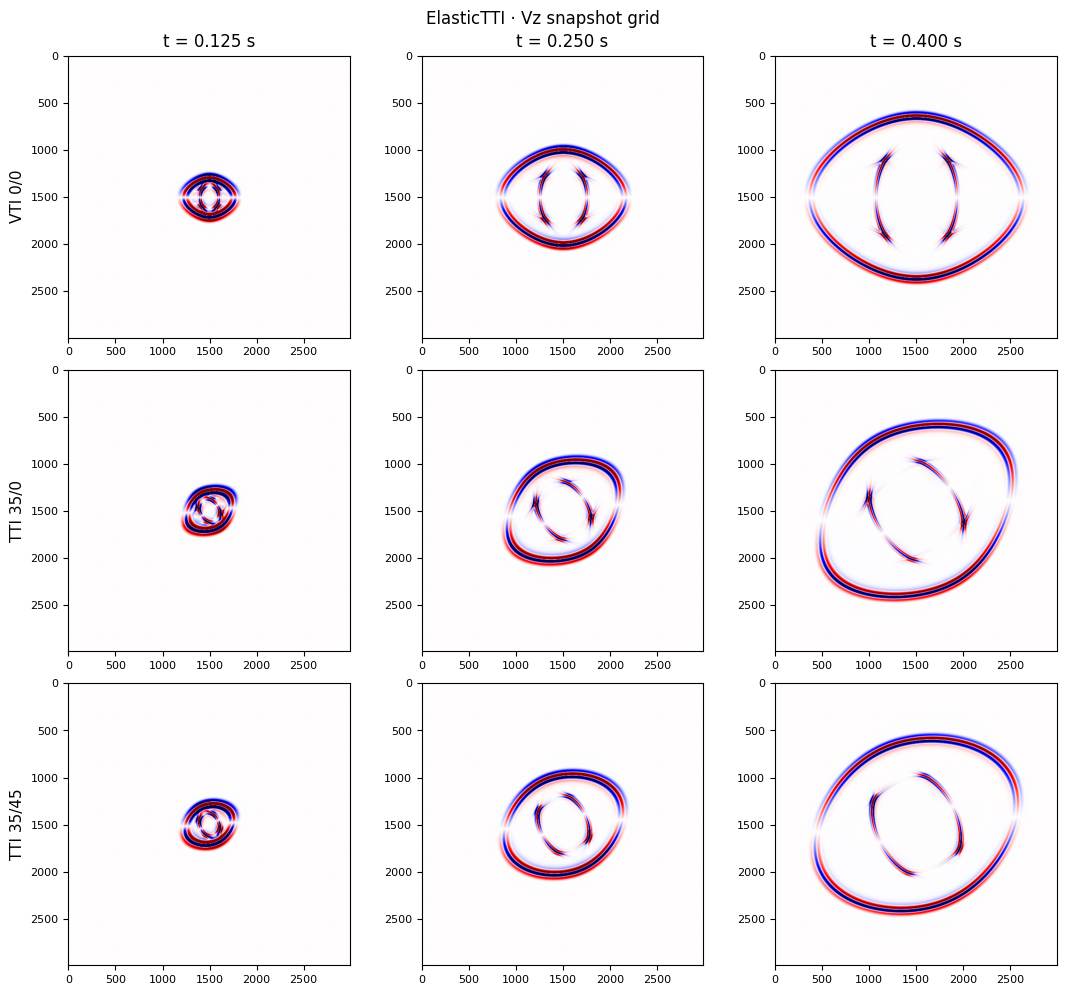

In [6]:
all_panels = [p for panels in snapshot_panels.values() for p in panels]
vmax = max(np.percentile(np.abs(p), 99.0) for p in all_panels)
extent = (0, (shape[1] - 1) * dh, (shape[0] - 1) * dh, 0)

ncols = len(snapshot_times)
fig, axes = plt.subplots(len(ROTATION_CASES), ncols,
                         figsize=(3.6 * ncols, 3.2 * len(ROTATION_CASES)),
                         constrained_layout=True)
for r, (label, _, _) in enumerate(ROTATION_CASES):
    for c, (panel, ts) in enumerate(zip(snapshot_panels[label], snapshot_times)):
        ax = axes[r, c]
        ax.imshow(panel, cmap='seismic', vmin=-vmax, vmax=vmax, aspect='equal', extent=extent)
        if r == 0: ax.set_title(f't = {ts * dt:.3f} s')
        if c == 0: ax.set_ylabel(label, fontsize=11)
        ax.tick_params(labelsize=8)
plt.suptitle('ElasticTTI · Vz snapshot grid', y=1.02)
plt.show()

---

<p><strong>Download this notebook</strong> &mdash; <a href="10_wavefield_elastic_tti.ipynb" download><code>10_wavefield_elastic_tti.ipynb</code></a> &middot; or <a href="https://github.com/DeepWave-KAUST/sweep/blob/dev/examples/notebooks/10_wavefield_elastic_tti.ipynb">view on GitHub</a></p>